# Data Cleaning

## Objective

The objective of this notebook is to improve the quality of the dataset before exploratory analysis. This includes identifying missing values, duplicate records, inconsistent data types, and other data quality issues. The cleaning process ensures that the dataset is reliable and suitable for meaningful analysis.

In [1]:
## Import Required Libraries

In [49]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [50]:
## Load the Dataset

In [51]:
df = pd.read_csv("../data/hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Create a Working Copy

The original dataset is preserved throughout the project. All cleaning operations are performed on a separate copy to maintain data integrity and allow reproducibility.

In [52]:
hotel_df = df.copy()

In [53]:
## Verify Dataset Shape

In [54]:
print(f"Rows    : {hotel_df.shape[0]}")
print(f"Columns : {hotel_df.shape[1]}")

Rows    : 119390
Columns : 32


In [55]:
## Assess Missing Values

In [56]:
missing_values = (
    hotel_df.isnull()
            .sum()
            .to_frame(name="Missing Values")
)

missing_values["Percentage (%)"] = (
    missing_values["Missing Values"] / len(hotel_df)
) * 100

missing_values = missing_values[
    missing_values["Missing Values"] > 0
].sort_values(
    by="Percentage (%)",
    ascending=False
)

missing_values

,Missing Values,Percentage (%)
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


## Missing Value Analysis

The dataset contains missing values in a few features. Before selecting an appropriate treatment, it is important to understand the extent of missing data and evaluate the significance of each feature. Different features may require different handling strategies based on their business relevance and percentage of missing values.

In [57]:
missing_values

,Missing Values,Percentage (%)
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


### 
Observation

The missing values are concentrated in a small number of features. Rather than applying a single imputation technique across all columns, each feature will be evaluated individually to determine the most appropriate treatment.

Section: Visualizing Missing Values

## Missing Value Distribution

The following visualization highlights the number of missing values present in each feature. This provides a quick overview of data completeness and helps identify columns requiring further attention.

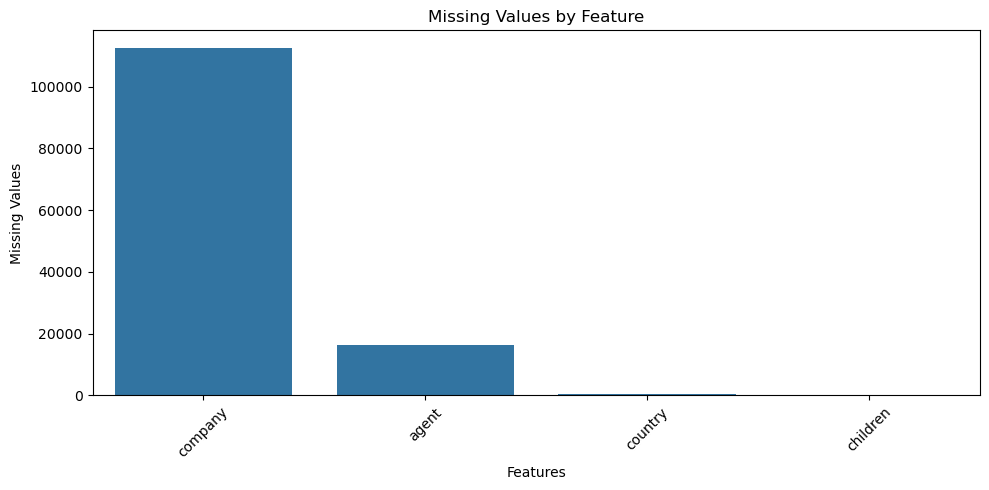

In [58]:
missing = hotel_df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Interpretation

The visualization indicates that missing values are primarily concentrated in a limited number of features. Features with a very high percentage of missing values require careful evaluation before deciding whether to retain, impute, or remove them from the analysis.

Section: Duplicate Record Analysis

In [59]:
## Duplicate Record Analysis

##Duplicate records can introduce bias into statistical analysis and affect the reliability of insights. This section evaluates the presence of duplicate observations before deciding whether they should be retained or removed.

In [60]:
duplicate_count = hotel_df.duplicated().sum()

print(f"Total Duplicate Records: {duplicate_count}")

Total Duplicate Records: 31994


In [61]:
duplicate_percentage = (duplicate_count / len(hotel_df)) * 100

print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

Duplicate Percentage: 26.80%


In [62]:
### Observation

##The dataset contains duplicate records. Before removing them, it is important to verify whether these duplicates represent repeated customer bookings or identical observations resulting from data collection. The decision to retain or remove duplicate records will be based on this assessment.

Section: Missing Value Treatment

In [63]:
## Missing Value Treatment Strategy

##Each feature is evaluated individually based on the percentage of missing values and its relevance to the analysis. Instead of applying a single imputation method to all variables, an appropriate strategy is selected for every feature.

In [64]:
missing_values

,Missing Values,Percentage (%)
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


### Proposed Treatment Strategy

| Feature | Missing Value (%) | Proposed Action | Reason |
|----------|------------------:|-----------------|--------|
| company | | Drop | More than 90% of the observations are missing, making the feature unsuitable for reliable analysis. |
| agent | | Impute if required | The feature contains useful information but has a moderate proportion of missing values. |
| country | | Fill with Mode | Only a small percentage of values are missing. |
| children | | Fill with Median | Very few observations are missing. |

Handle Missing Values

In [65]:
## Handling Missing Values

#Based on the previous assessment, missing values are handled using feature-specific strategies. The objective is to preserve useful information while minimizing the impact of incomplete records on subsequent analysis.

In [66]:
#drop company
hotel_df.drop(columns="company", inplace=True)

In [67]:
hotel_df["agent"] = hotel_df["agent"].fillna(0)

In [68]:
hotel_df["country"] = hotel_df["country"].fillna(
    hotel_df["country"].mode()[0]
)

In [69]:
hotel_df["children"] = hotel_df["children"].fillna(
    hotel_df["children"].median()
)

Verify Missing Values

In [70]:
## Verify Missing Values

#The dataset is re-evaluated to confirm that all missing values have been handled successfully.

In [71]:
hotel_df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

Remove Duplicate Records

In [72]:
hotel_df.drop_duplicates(inplace=True)

In [74]:
#verify
print(f"Rows after removing duplicates: {hotel_df.shape[0]}")
print(f"Remaining duplicate records: {hotel_df.duplicated().sum()}")

Rows after removing duplicates: 87370
Remaining duplicate records: 0


Save the Cleaned Dataset

In [75]:
## Save Cleaned Dataset

#The cleaned dataset is saved for use in subsequent notebooks. This ensures that all future analysis is performed on a consistent and preprocessed version of the data.

In [76]:
hotel_df.to_csv("../data/hotel_bookings_cleaned.csv", index=False)

In [77]:
## Summary

#The data cleaning process addressed the major data quality issues identified during the assessment. Missing values were handled using feature-specific strategies, duplicate records were removed, and the cleaned dataset was exported for use in the exploratory data analysis phase.